In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from skmap.misc import find_files, GoogleSheet, ttprint
import warnings
import multiprocess as mp
import time
from scipy.special import expit, logit
import warnings
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, HalvingGridSearchCV, KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor 
import joblib
import pickle
from sklearn.metrics import r2_score, mean_squared_error, make_scorer#, root_mean_squared_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
# from cubist import Cubist
from sklearn.base import BaseEstimator, TransformerMixin
from pathlib import Path
from trees_rf import TreesRandomForestRegressor
from model_fit import read_features, cfi_calc, parameter_fine_tuning, calc_ccc, separate_data, rscfi 
from model_fit import accuracy_plot, plot_top_features, pdp_hexbin, plot_histogram, calc_metrics, accuracy_strata_plot
import warnings
warnings.filterwarnings('ignore')
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import json
from datetime import datetime

folder_path = '/mnt/ripley/global_soc/scikit-map/global-soil-mapping'
# prop_list = ['ocd', 'soc', 'bulk.density', 'ph.h2o', 'coarse']
prop_list = ['ocd', 'soc', 'ph.h2o']
transforms_dict = {
    'ocd': 'log1p',
    'soc': 'log1p',
    'bulk.density': None,
    'ph.h2o': None,
    'coarse': 'log1p'
}
version = '20250204_clean'

min_convs_num = 60
max_convs_num = 120

# Separate Calibration (Cal), Train, and Test Data

Perform this separation **only once**, then save and read the separated data to ensure reproducibility.

#### Data ratio:
- **When data is limited**: Maintain the ratio between calibration, train, and test sets as `1:8:1`.
- **When data is abundant**: Allocate around **8,000 samples** for calibration and **6,000 samples** for testing.

#### How:
- **Strata with very few samples** (`count < 3`): Randomly assign samples to a set.
- **Strata with few samples** (`3 ≤ count < 10`): Distribute samples evenly across the sets.
- **Strata with sufficient samples** (`count ≥ 10`): Assign samples according to the specified ratio.


# Model calibration

In [3]:
with open(f'{folder_path}/material/soil_cov_no.bimonthly.landsat_v{version}.json', "r") as file:
    covar_cols = json.load(file)
print('total cov number: ', len(covar_cols))

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    # elif space=='boxcox':
    #     # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
    #     tgt = f'{prop}_boxcox'
    #     cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    # read existing results
    cal = pd.read_parquet(f'{output_folder}/data_cal_{prop}_v{version}.pq')
    
    # # feature selection
    print('feature selection********************')
    cfi = cfi_calc(cal, tgt, prop, space, output_folder, version, covar_cols) # produce
    


total cov number:  275

ocd--------------------------------------------------------------
feature selection********************
start bootstrap on different subset...
[12:36:09] 0 iteration, training size: 5522
[12:36:38] 1 iteration, training size: 5522
[12:37:06] 2 iteration, training size: 5522
[12:37:32] 3 iteration, training size: 5522
[12:37:58] 4 iteration, training size: 5522
[12:38:24] 5 iteration, training size: 5522
[12:38:50] 6 iteration, training size: 5522
[12:39:16] 7 iteration, training size: 5522
[12:39:42] 8 iteration, training size: 5522
[12:40:07] 9 iteration, training size: 5522
[12:40:33] 10 iteration, training size: 5522
[12:40:59] 11 iteration, training size: 5522
[12:41:24] 12 iteration, training size: 5522
[12:41:51] 13 iteration, training size: 5522
[12:42:18] 14 iteration, training size: 5522
[12:42:43] 15 iteration, training size: 5522
[12:43:10] 16 iteration, training size: 5522
[12:43:35] 17 iteration, training size: 5522
[12:44:01] 18 iteration, training

total cov number:  275

ocd--------------------------------------------------------------
[13:07:17] processing -0.0001405508200037 ...
[13:07:25] processing 0.0 ...
[13:07:33] processing 5.94491799963e-05 ...
[13:07:40] processing 0.0002594491799963 ...
[13:07:44] processing 0.00045944917999630005 ...
[13:07:46] processing 0.0006594491799963001 ...
[13:07:49] processing 0.0008594491799963 ...
[13:07:51] processing 0.0010594491799963 ...
[13:07:52] processing 0.0012594491799963 ...
[13:07:53] processing 0.0014594491799963 ...
[13:07:55] processing 0.0016594491799963 ...
[13:07:56] processing 0.0018594491799963 ...
[13:07:57] processing 0.0020594491799963 ...
[13:07:58] processing 0.0022594491799963 ...
[13:07:59] processing 0.0026594491799963 ...
[13:08:00] processing 0.0028594491799963 ...
[13:08:01] processing 0.0030594491799963 ...
[13:08:02] processing 0.0032594491799963 ...
[13:08:04] processing 0.0034594491799963003 ...
[13:08:05] processing 0.0038594491799963 ...
[13:08:06] proc

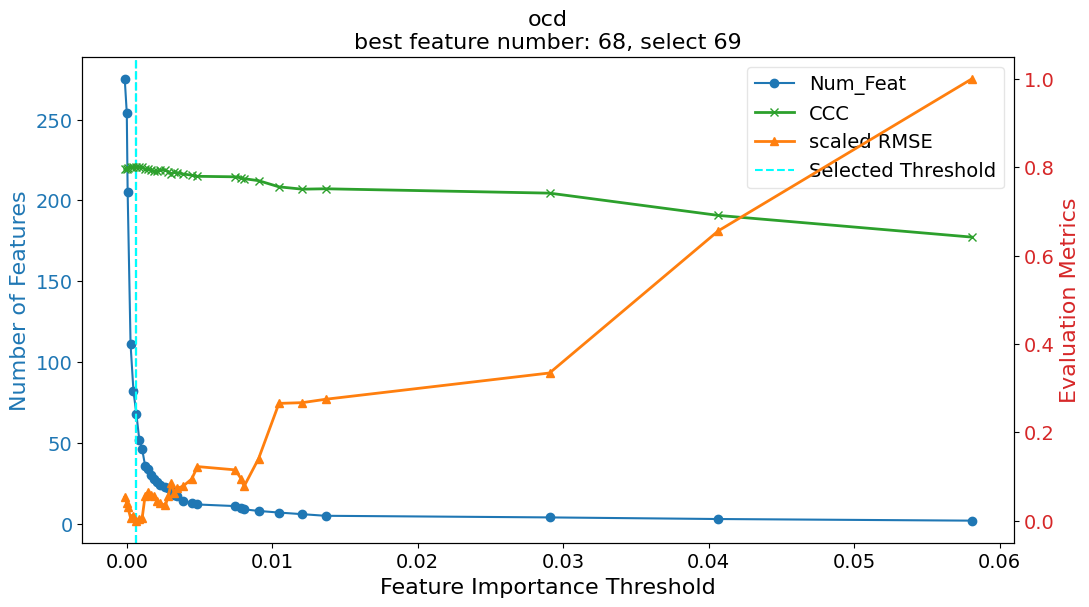

parameter fine tuning****************
[13:08:13] ----------------------rf------------------------
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 97
max_resources_: 7889
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 135
n_resources: 97
Fitting 5 folds for each of 135 candidates, totalling 675 fits
----------
iter: 1
n_candidates: 45
n_resources: 291
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 2
n_candidates: 15
n_resources: 873
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 3
n_candidates: 5
n_resources: 2619
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 2
n_resources: 7857
Fitting 5 folds for each of 2 candidates, totalling 10 fits

soc--------------------------------------------------------------
[13:08:46] processing -0.0003024482729344 ...
[13:08:55] processing -0.00010244827293439998 ...
[13:09:03] processing 

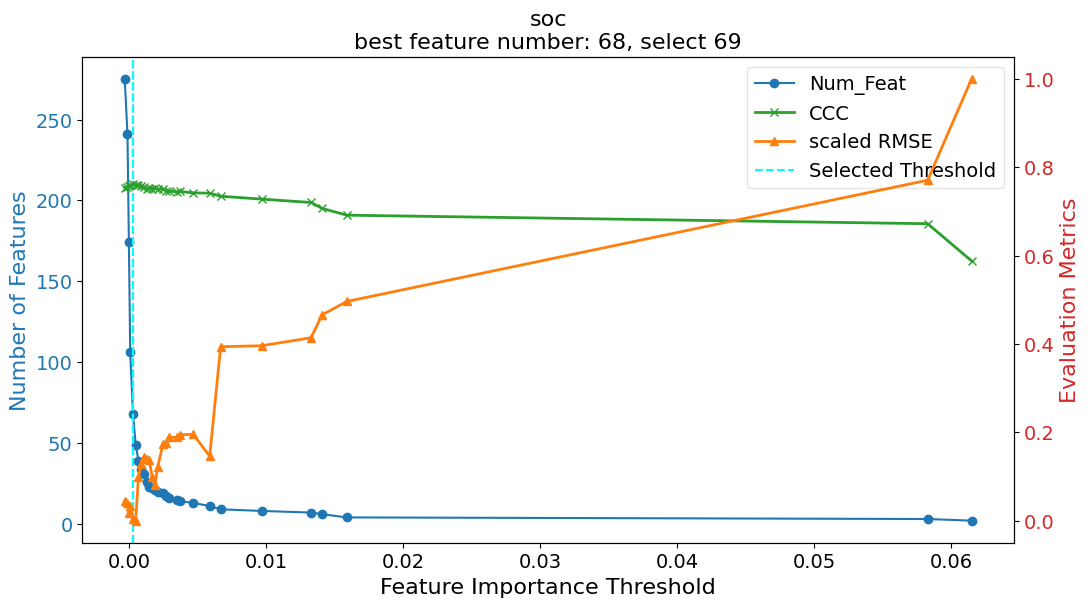

parameter fine tuning****************
[13:09:38] ----------------------rf------------------------
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 98
max_resources_: 7975
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 135
n_resources: 98
Fitting 5 folds for each of 135 candidates, totalling 675 fits
----------
iter: 1
n_candidates: 45
n_resources: 294
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 2
n_candidates: 15
n_resources: 882
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 3
n_candidates: 5
n_resources: 2646
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 2
n_resources: 7938
Fitting 5 folds for each of 2 candidates, totalling 10 fits

ph.h2o--------------------------------------------------------------
[13:10:16] processing -0.0001186761867557 ...
[13:10:25] processing 0.0 ...
[13:10:33] processing 8.132381324430001

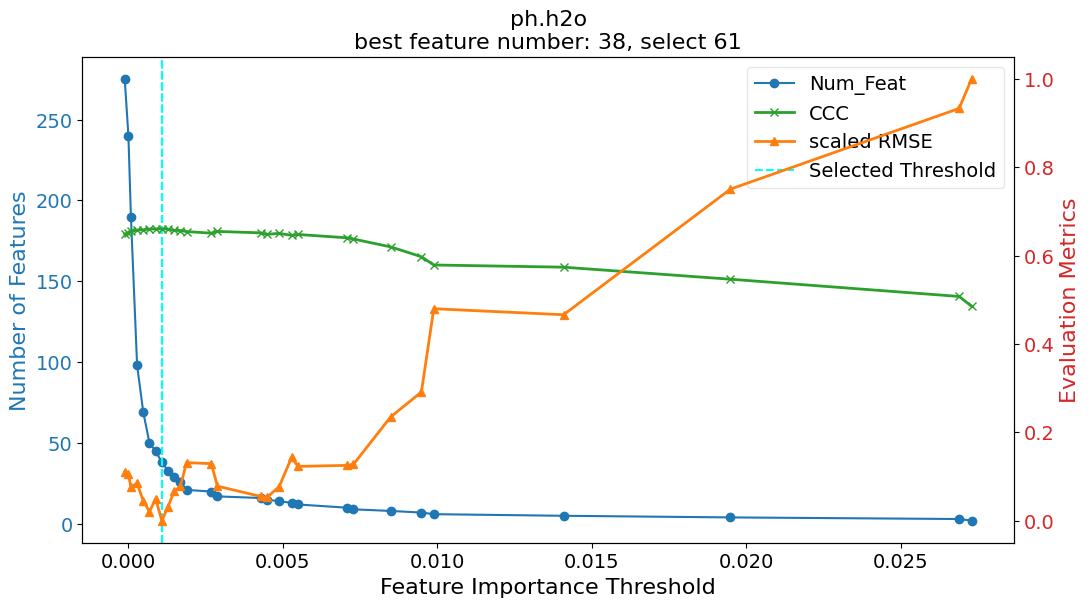

parameter fine tuning****************
[13:11:09] ----------------------rf------------------------
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 97
max_resources_: 7890
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 135
n_resources: 97
Fitting 5 folds for each of 135 candidates, totalling 675 fits
----------
iter: 1
n_candidates: 45
n_resources: 291
Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------
iter: 2
n_candidates: 15
n_resources: 873
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 3
n_candidates: 5
n_resources: 2619
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 2
n_resources: 7857
Fitting 5 folds for each of 2 candidates, totalling 10 fits


In [4]:
with open(f'{folder_path}/material/soil_cov_no.bimonthly.landsat_v{version}.json', "r") as file:
    covar_cols = json.load(file)
print('total cov number: ', len(covar_cols))

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    # elif space=='boxcox':
    #     # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
    #     tgt = f'{prop}_boxcox'
    #     cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
        
    cal = pd.read_parquet(f'{output_folder}/data_cal_{prop}_v{version}.pq')
    cfi = pd.read_csv(f'{output_folder}/feature_cfi_{prop}_v{version}.csv') # read in
    covs = rscfi(cal, tgt, prop, space, output_folder, version, covar_cols, cfi, min_convs_num, max_convs_num, step_size=0.0002) # produce
         
    
    # ## read in existing results
    # covs = read_features(f'{output_folder}/feature_selected_{prop}_v{version}.txt') # read in
    ## parameter fine-tuning
    print('parameter fine tuning****************')
    models, model_names = parameter_fine_tuning(cal, covs, tgt, prop, output_folder, version)